# Phase 1 — Dataset Inspection (look-only)

House-rent **regression** experiment. This notebook only *inspects* `House_Rent_Dataset.csv`:
it **modifies nothing, saves nothing, and drops no rows**. Any parsing done here (e.g. `Floor`,
dates) goes into throw-away local variables purely to *look* at the data.

**Output = a documented list of decisions** (last cell) that feed Phases 2–5.

Colab: upload `House_Rent_Dataset.csv` into the working directory, then *Runtime → Run all*.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("House_Rent_Dataset.csv")   # raw, read-only for this phase
TARGET = "Rent"
print("Loaded:", df.shape)

Loaded: (4746, 12)


## 1. Glossary cross-check

In [2]:
GLOSSARY = {
    "BHK": "Number of Bedrooms, Hall, Kitchen",
    "Rent": "Rent of the Houses/Apartments/Flats",
    "Size": "Size in Square Feet",
    "Floor": "Floor and total number of floors (e.g. 'Ground out of 2', '3 out of 5')",
    "Area Type": "Size calculated on Super Area / Carpet Area / Build Area",
    "Area Locality": "Locality of the property",
    "City": "City where the property is located",
    "Furnishing Status": "Furnished / Semi-Furnished / Unfurnished",
    "Tenant Preferred": "Type of tenant preferred by owner or agent",
    "Bathroom": "Number of bathrooms",
    "Point of Contact": "Whom to contact for more information",
}
in_data_not_glossary = [c for c in df.columns if c not in GLOSSARY]
in_glossary_not_data = [c for c in GLOSSARY if c not in df.columns]
print("Columns in data but NOT in glossary :", in_data_not_glossary)
print("Columns in glossary but NOT in data :", in_glossary_not_data)
print("\nGlossary says Area Type values = Super/Carpet/'Build' Area; data has:",
      sorted(df["Area Type"].unique()))
print("Glossary says Furnishing values = Furnished/Semi-Furnished/Unfurnished; data has:",
      sorted(df["Furnishing Status"].unique()))

Columns in data but NOT in glossary : ['Posted On']
Columns in glossary but NOT in data : []

Glossary says Area Type values = Super/Carpet/'Build' Area; data has: ['Built Area', 'Carpet Area', 'Super Area']
Glossary says Furnishing values = Furnished/Semi-Furnished/Unfurnished; data has: ['Furnished', 'Semi-Furnished', 'Unfurnished']


## 2. Shape, dtypes, sample

In [3]:
print("Shape:", df.shape)
display(df.dtypes.to_frame("dtype"))
display(df.head())

Shape: (4746, 12)


,dtype
Posted On,str
BHK,int64
Rent,int64
Size,int64
Floor,str
Area Type,str
Area Locality,str
City,str
Furnishing Status,str
Tenant Preferred,str


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## 3. Missing values & duplicates

In [4]:
miss = df.isna().sum()
print("Missing values per column:\n", miss.to_string())
print("\nTotal missing:", int(miss.sum()))

# Also look for disguised missing values in text columns (blank / 'NA' / '-' strings)
obj_cols = df.select_dtypes(exclude="number").columns
disguised = {c: int(df[c].astype(str).str.strip().str.lower().isin(["", "na", "n/a", "none", "null", "-", "nan"]).sum())
             for c in obj_cols}
print("Disguised-missing strings per text column:", disguised)

print("\nExact duplicate rows                     :", int(df.duplicated().sum()))
print("Duplicates ignoring 'Posted On'          :", int(df.drop(columns="Posted On").duplicated().sum()))
print("Duplicates ignoring 'Posted On' & Rent   :",
      int(df.drop(columns=["Posted On", "Rent"]).duplicated().sum()))
dup_mask = df.drop(columns="Posted On").duplicated(keep=False)
display(df[dup_mask].sort_values(["City", "Area Locality", "Size"]).head(16))

Missing values per column:
 Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0

Total missing: 0
Disguised-missing strings per text column: {'Posted On': 0, 'Floor': 0, 'Area Type': 0, 'Area Locality': 0, 'City': 0, 'Furnishing Status': 0, 'Tenant Preferred': 0, 'Point of Contact': 0}

Exact duplicate rows                     : 0
Duplicates ignoring 'Posted On'          : 8
Duplicates ignoring 'Posted On' & Rent   : 25


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
2535,2022-06-04,1,20000,400,3 out of 4,Carpet Area,Lajpat Nagar 4,Delhi,Furnished,Bachelors/Family,1,Contact Agent
2793,2022-05-27,1,20000,400,3 out of 4,Carpet Area,Lajpat Nagar 4,Delhi,Furnished,Bachelors/Family,1,Contact Agent
2616,2022-07-04,4,42000,2700,2 out of 4,Carpet Area,"Pushpanjali, Anand Vihar",Delhi,Semi-Furnished,Bachelors,4,Contact Agent
2669,2022-05-26,4,42000,2700,2 out of 4,Carpet Area,"Pushpanjali, Anand Vihar",Delhi,Semi-Furnished,Bachelors,4,Contact Agent
2580,2022-05-23,1,8000,200,2 out of 4,Carpet Area,kst chattarpur Apartments,Delhi,Unfurnished,Bachelors,1,Contact Agent
2581,2022-05-27,1,8000,200,2 out of 4,Carpet Area,kst chattarpur Apartments,Delhi,Unfurnished,Bachelors,1,Contact Agent
2758,2022-06-04,2,13000,400,2 out of 4,Carpet Area,kst chattarpur Apartments,Delhi,Unfurnished,Bachelors,1,Contact Agent
2837,2022-05-14,2,13000,400,2 out of 4,Carpet Area,kst chattarpur Apartments,Delhi,Unfurnished,Bachelors,1,Contact Agent
133,2022-07-01,1,4700,250,1 out of 2,Super Area,Kaikhali,Kolkata,Furnished,Bachelors/Family,1,Contact Owner
203,2022-06-12,1,4700,250,1 out of 2,Super Area,Kaikhali,Kolkata,Furnished,Bachelors/Family,1,Contact Owner


## 4. Unique counts, column roles, cardinality

In [5]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "unique_ratio": (df.nunique() / len(df)).round(4),
    "top_value_share": df.apply(lambda s: s.value_counts(normalize=True).iloc[0]).round(4),
    "role": ["numeric" if c in num_cols else "categorical/text" for c in df.columns],
})
display(summary)
print("Numeric     :", num_cols)
print("Categorical :", cat_cols)
print("\nID-like columns (unique_ratio > 0.95):", summary.index[summary.unique_ratio > 0.95].tolist())
print("Constant columns (n_unique == 1)      :", summary.index[summary.n_unique == 1].tolist())
print("Near-constant (top share > 0.95)      :", summary.index[summary.top_value_share > 0.95].tolist())

,dtype,n_unique,unique_ratio,top_value_share,role
Posted On,str,81,0.0171,0.0655,categorical/text
BHK,int64,6,0.0013,0.4772,numeric
Rent,int64,243,0.0512,0.0579,numeric
Size,int64,615,0.1296,0.0506,numeric
Floor,str,480,0.1011,0.0799,categorical/text
Area Type,str,3,0.0006,0.5154,categorical/text
Area Locality,str,2235,0.4709,0.0078,categorical/text
City,str,6,0.0013,0.2048,categorical/text
Furnishing Status,str,3,0.0006,0.4743,categorical/text
Tenant Preferred,str,3,0.0006,0.7257,categorical/text


Numeric     : ['BHK', 'Rent', 'Size', 'Bathroom']
Categorical : ['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']

ID-like columns (unique_ratio > 0.95): []
Constant columns (n_unique == 1)      : []
Near-constant (top share > 0.95)      : []


In [6]:
low_card = ["City", "Area Type", "Furnishing Status", "Tenant Preferred", "Point of Contact", "BHK", "Bathroom"]
for c in low_card:
    vc = df[c].value_counts()
    rare = vc[vc < 10].to_dict()
    print(f"{c:18s} levels={len(vc):2d}  {vc.to_dict()}" + (f"   <-- RARE (<10): {rare}" if rare else ""))

City               levels= 6  {'Mumbai': 972, 'Chennai': 891, 'Bangalore': 886, 'Hyderabad': 868, 'Delhi': 605, 'Kolkata': 524}
Area Type          levels= 3  {'Super Area': 2446, 'Carpet Area': 2298, 'Built Area': 2}   <-- RARE (<10): {'Built Area': 2}
Furnishing Status  levels= 3  {'Semi-Furnished': 2251, 'Unfurnished': 1815, 'Furnished': 680}
Tenant Preferred   levels= 3  {'Bachelors/Family': 3444, 'Bachelors': 830, 'Family': 472}
Point of Contact   levels= 3  {'Contact Owner': 3216, 'Contact Agent': 1529, 'Contact Builder': 1}   <-- RARE (<10): {'Contact Builder': 1}
BHK                levels= 6  {2: 2265, 1: 1167, 3: 1098, 4: 189, 5: 19, 6: 8}   <-- RARE (<10): {6: 8}
Bathroom           levels= 8  {2: 2291, 1: 1474, 3: 749, 4: 156, 5: 60, 6: 12, 7: 3, 10: 1}   <-- RARE (<10): {7: 3, 10: 1}


### 4a. `Area Locality` — high-cardinality check

In [7]:
loc = df["Area Locality"]
vc = loc.value_counts()
norm = loc.str.lower().str.replace(r"[^a-z0-9 ]", " ", regex=True).str.split().str.join(" ")
print(f"Unique localities                 : {loc.nunique()}  ({loc.nunique()/len(df):.1%} of rows)")
print(f"Unique after lower/strip/punct    : {norm.nunique()}")
print(f"Localities seen exactly once      : {(vc == 1).sum()}  ({(vc == 1).sum()/loc.nunique():.1%} of localities)")
print(f"Rows in localities with < 5 rows  : {loc.map(vc).lt(5).mean():.1%}")
print(f"Localities appearing in >1 city   : {(df.groupby('Area Locality')['City'].nunique() > 1).sum()}")
print("\nTop 10:\n", vc.head(10).to_string())
print("\nExamples of free-text noise:", loc[loc.str.len() > 60].head(3).tolist())

Unique localities                 : 2235  (47.1% of rows)
Unique after lower/strip/punct    : 2228
Localities seen exactly once      : 1465  (65.5% of localities)
Rows in localities with < 5 rows  : 60.6%
Localities appearing in >1 city   : 4

Top 10:
 Area Locality
Bandra West        37
Gachibowli         29
Electronic City    24
Velachery          22
Miyapur, NH 9      22
Madipakkam         20
Chembur            19
K R Puram          19
Laxmi Nagar        19
Kondapur           18

Examples of free-text noise: ['Biren Roy Road (W) Chowrashtra Behala, Raja Rammohan Roy Road', 'No 309 6th A cross Banashankari 1st stage 2nd block Bangalore 560050', 'Hormany nest Apartments gandipet Apartmentge hyderabad, Hyderabad']


## 5. `Floor` — format check (parsed into a throw-away variable, df untouched)

In [8]:
fl = df["Floor"]
has_out_of = fl.str.contains(" out of ", regex=False)
print("Rows WITHOUT 'out of' (no total-floors info):", int((~has_out_of).sum()), fl[~has_out_of].tolist())
_parts = fl.str.split(" out of ", n=1, expand=True)
_cur, _tot = _parts[0], _parts[1]
print("Non-numeric 'current floor' tokens:", _cur[~_cur.str.isdigit()].value_counts().to_dict())
print("Non-numeric 'total floors' tokens :", _tot.dropna()[~_tot.dropna().str.isdigit()].value_counts().to_dict())
_tot_num = pd.to_numeric(_tot, errors="coerce")
_cur_num = pd.to_numeric(_cur.replace({"Ground": "0", "Upper Basement": "-1", "Lower Basement": "-2"}), errors="coerce")
print("\nTotal floors range:", _tot_num.min(), "–", _tot_num.max())
print("Rows where current floor > total floors (inconsistent):", int((_cur_num > _tot_num).sum()))
print("Spearman(current floor, Rent):", round(stats.spearmanr(_cur_num, df[TARGET], nan_policy='omit')[0], 3))
print("Spearman(total floors,  Rent):", round(stats.spearmanr(_tot_num, df[TARGET], nan_policy='omit')[0], 3))

Rows WITHOUT 'out of' (no total-floors info): 4 ['3', 'Ground', '1', '1']
Non-numeric 'current floor' tokens: {'Ground': 927, 'Upper Basement': 23, 'Lower Basement': 11}
Non-numeric 'total floors' tokens : {}

Total floors range: 1.0 – 89.0
Rows where current floor > total floors (inconsistent): 2
Spearman(current floor, Rent): 0.483
Spearman(total floors,  Rent): 0.582


## 6. Target distribution — `Rent`

,Rent (₹),log1p(Rent)
min,1200.000,7.091
max,3500000.000,15.068
mean,34993.451,9.878
median,16000.000,9.680
std,78106.413,0.937
skew,21.410,0.909
kurtosis,841.108,0.877


Percentiles (₹): {0.01: 4000.0, 0.05: 6000.0, 0.25: 10000.0, 0.5: 16000.0, 0.75: 33000.0, 0.95: 130000.0, 0.99: 300000.0, 0.999: 685100.0}


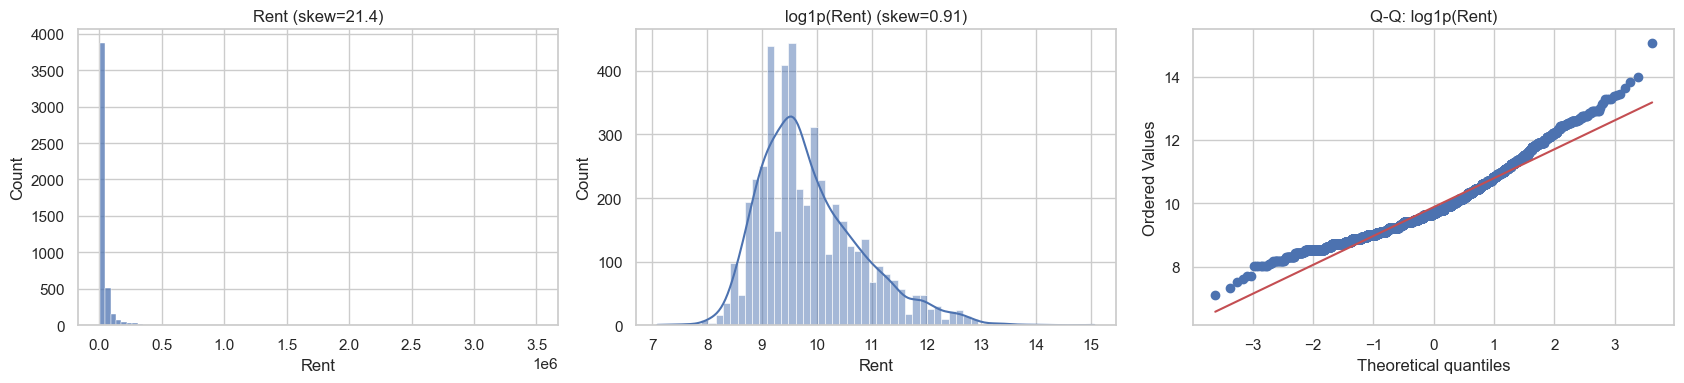

In [9]:
def describe(s):
    return pd.Series({"min": s.min(), "max": s.max(), "mean": s.mean(), "median": s.median(),
                      "std": s.std(), "skew": s.skew(), "kurtosis": s.kurt()})
log_rent = np.log1p(df[TARGET])
display(pd.DataFrame({"Rent (₹)": describe(df[TARGET]), "log1p(Rent)": describe(log_rent)}).round(3))
print("Percentiles (₹):", df[TARGET].quantile([.01, .05, .25, .5, .75, .95, .99, .999]).round(0).to_dict())

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(df[TARGET], bins=80, ax=ax[0]); ax[0].set_title(f"Rent (skew={df[TARGET].skew():.1f})")
sns.histplot(log_rent, bins=60, kde=True, ax=ax[1]); ax[1].set_title(f"log1p(Rent) (skew={log_rent.skew():.2f})")
stats.probplot(log_rent, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q: log1p(Rent)")
plt.tight_layout(); plt.show()

## 7. Potential outliers & suspicious values (inspected, NOT removed)

In [10]:
def iqr_count(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    lo, hi = q1 - 1.5 * i, q3 + 1.5 * i
    return pd.Series({"lower_fence": lo, "upper_fence": hi, "n_below": int((s < lo).sum()), "n_above": int((s > hi).sum())})
out = pd.DataFrame({
    "Rent": iqr_count(df["Rent"]), "log1p(Rent)": iqr_count(log_rent),
    "Size": iqr_count(df["Size"]), "log1p(Size)": iqr_count(np.log1p(df["Size"])),
    "BHK": iqr_count(df["BHK"]), "Bathroom": iqr_count(df["Bathroom"]),
}).T
display(out.round(2))
print("|z| > 3 on log1p(Rent):", int((np.abs(stats.zscore(log_rent)) > 3).sum()))

print("\nTop-5 rents (look only):")
display(df.nlargest(5, "Rent")[["Rent", "Size", "BHK", "Bathroom", "City", "Area Locality", "Furnishing Status"]])
print("Bottom-5 rents (look only):")
display(df.nsmallest(5, "Rent")[["Rent", "Size", "BHK", "Bathroom", "City", "Area Locality"]])

,lower_fence,upper_fence,n_below,n_above
Rent,-24500.00,67500.00,0.0,520.0
log1p(Rent),7.42,12.20,2.0,114.0
Size,-425.00,2175.00,0.0,203.0
log1p(Size),5.14,8.26,186.0,25.0
BHK,0.50,4.50,0.0,27.0
Bathroom,-0.50,3.50,0.0,232.0


|z| > 3 on log1p(Rent): 37

Top-5 rents (look only):


,Rent,Size,BHK,Bathroom,City,Area Locality,Furnishing Status
1837,3500000,2500,3,3,Bangalore,Marathahalli,Semi-Furnished
1001,1200000,5000,4,4,Mumbai,Juhu,Semi-Furnished
827,1000000,3064,4,4,Mumbai,"Raheja Artesia, Worli",Semi-Furnished
1329,850000,3200,4,4,Mumbai,Breach Candy,Furnished
1459,700000,3200,4,4,Mumbai,"Lady Ratan Tower, Worli",Furnished


Bottom-5 rents (look only):


,Rent,Size,BHK,Bathroom,City,Area Locality
4076,1200,2100,3,3,Hyderabad,"Uppal, NH 2 2"
285,1500,200,1,1,Kolkata,Santoshpur
471,1800,500,1,1,Kolkata,Shyam Bazar
2475,2000,60,2,1,Delhi,Ram Nagar
146,2200,550,2,1,Kolkata,Behala silpara


In [11]:
size_per_bhk = df["Size"] / df["BHK"]
rent_per_sqft = df["Rent"] / df["Size"]
checks = {
    "Rent <= 0": (df["Rent"] <= 0).sum(),
    "Size <= 0": (df["Size"] <= 0).sum(),
    "Size < 100 sqft": (df["Size"] < 100).sum(),
    "Size/BHK < 100 sqft": (size_per_bhk < 100).sum(),
    "BHK <= 0 or Bathroom <= 0": ((df["BHK"] <= 0) | (df["Bathroom"] <= 0)).sum(),
    "Bathroom > BHK + 2": (df["Bathroom"] > df["BHK"] + 2).sum(),
}
for k, v in checks.items():
    print(f"{k:28s}: {int(v)}")
print("\nSmallest sizes (look only):")
display(df.nsmallest(6, "Size")[["Size", "BHK", "Bathroom", "Rent", "City", "Area Type"]])
print("Rent per sqft percentiles:", rent_per_sqft.quantile([.001, .01, .5, .99, .999]).round(1).to_dict())

Rent <= 0                   : 0
Size <= 0                   : 0
Size < 100 sqft             : 91
Size/BHK < 100 sqft         : 172
BHK <= 0 or Bathroom <= 0   : 0
Bathroom > BHK + 2          : 4

Smallest sizes (look only):


,Size,BHK,Bathroom,Rent,City,Area Type
4653,10,3,3,15000,Hyderabad,Carpet Area
116,20,1,1,5000,Kolkata,Super Area
2460,25,1,1,5000,Delhi,Carpet Area
2913,25,1,1,3500,Delhi,Super Area
2973,25,1,1,6000,Delhi,Super Area
3922,25,3,3,23000,Hyderabad,Carpet Area


Rent per sqft percentiles: {0.001: 3.6, 0.01: 6.6, 0.5: 20.0, 0.99: 240.3, 0.999: 705.1}


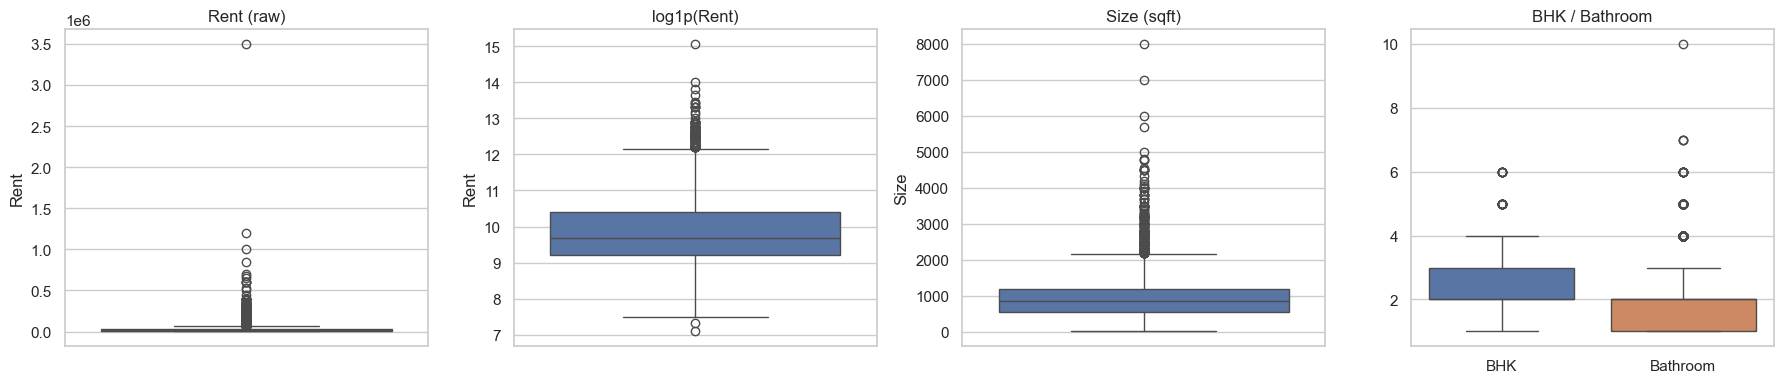

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
sns.boxplot(y=df["Rent"], ax=ax[0]); ax[0].set_title("Rent (raw)")
sns.boxplot(y=log_rent, ax=ax[1]); ax[1].set_title("log1p(Rent)")
sns.boxplot(y=df["Size"], ax=ax[2]); ax[2].set_title("Size (sqft)")
sns.boxplot(data=df[["BHK", "Bathroom"]], ax=ax[3]); ax[3].set_title("BHK / Bathroom")
plt.tight_layout(); plt.show()

## 8. Relationships with the target & correlation

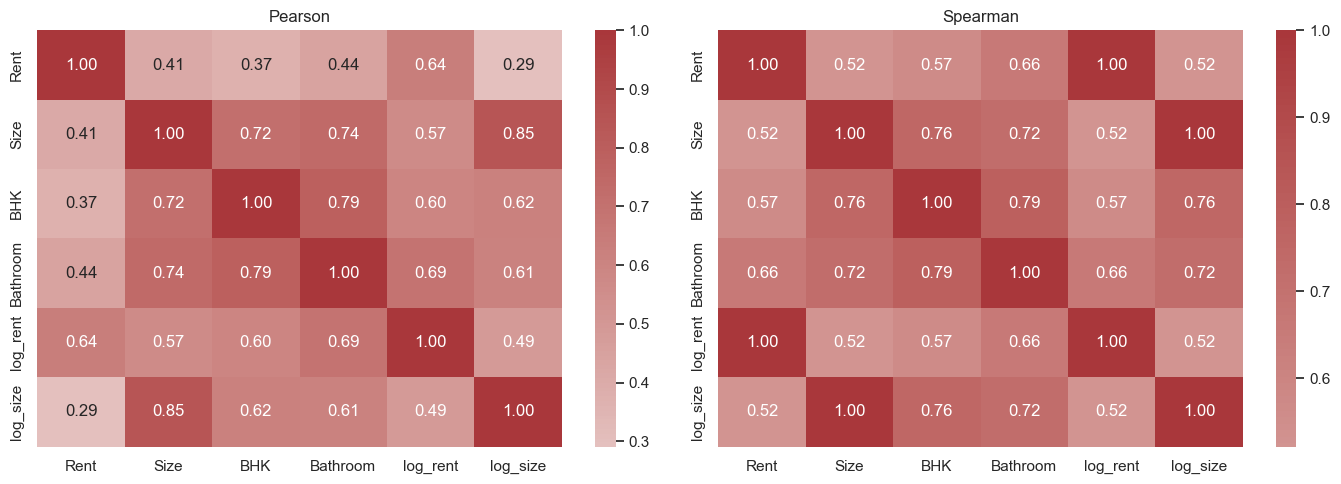

In [13]:
num = df[["Rent", "Size", "BHK", "Bathroom"]].assign(log_rent=log_rent, log_size=np.log1p(df["Size"]))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(num.corr(method="pearson"), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[0]); ax[0].set_title("Pearson")
sns.heatmap(num.corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[1]); ax[1].set_title("Spearman")
plt.tight_layout(); plt.show()

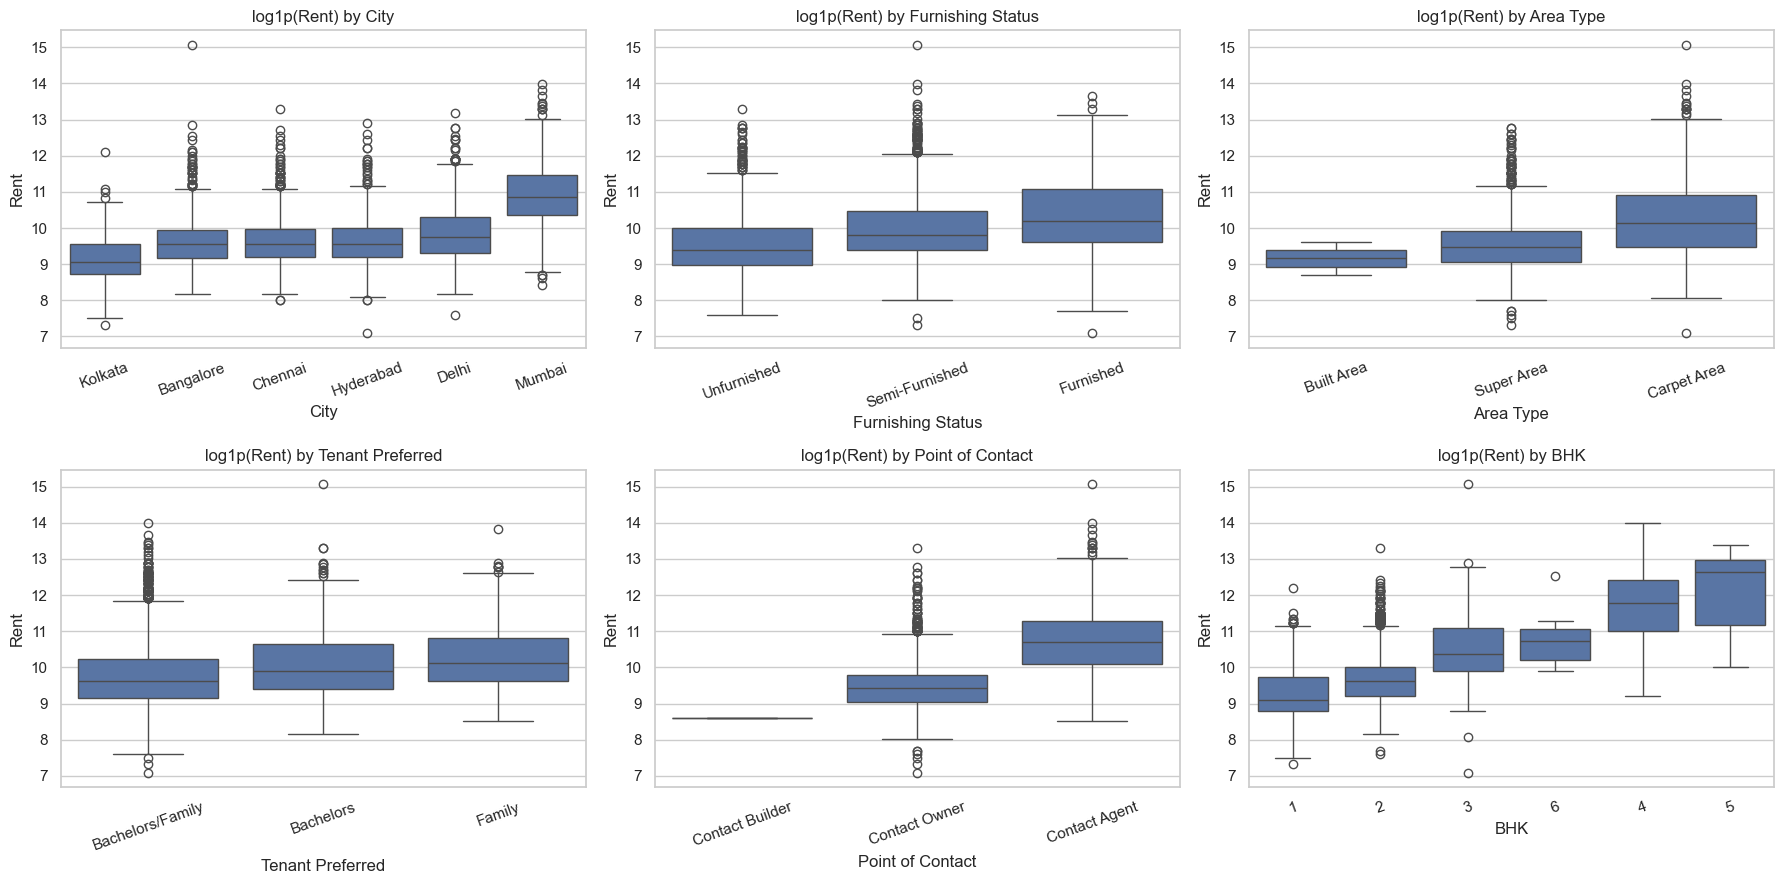


City:
            count   median     mean
City                              
Kolkata      524   8500.0  11645.0
Bangalore    886  14000.0  24966.0
Chennai      891  14000.0  21614.0
Hyderabad    868  14000.0  20555.0
Delhi        605  17000.0  29462.0
Mumbai       972  52000.0  85321.0

Furnishing Status:
                    count   median     mean
Furnishing Status                         
Unfurnished         1815  12000.0  22462.0
Semi-Furnished      2251  18000.0  38719.0
Furnished            680  27000.0  56110.0

Area Type:
              count   median     mean
Area Type                           
Built Area       2  10500.0  10500.0
Super Area    2446  13000.0  18673.0
Carpet Area   2298  25000.0  52386.0

Tenant Preferred:
                   count   median     mean
Tenant Preferred                         
Bachelors/Family   3444  15000.0  31211.0
Bachelors           830  20000.0  42144.0
Family              472  25000.0  50020.0

Point of Contact:
                   count   me

In [14]:
cats = ["City", "Furnishing Status", "Area Type", "Tenant Preferred", "Point of Contact", "BHK"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for c, a in zip(cats, axes.ravel()):
    order = df.groupby(c)["Rent"].median().sort_values().index
    sns.boxplot(x=df[c], y=log_rent, order=order, ax=a)
    a.set_title(f"log1p(Rent) by {c}"); a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

for c in cats[:-1]:
    g = df.groupby(c)["Rent"].agg(["count", "median", "mean"]).sort_values("median")
    print(f"\n{c}:\n", g.round(0).to_string())

In [15]:
# Association strength of each categorical with log-rent (correlation ratio eta^2) — look only
def eta_sq(cat, y):
    g = y.groupby(cat); grand = y.mean()
    return float((g.count() * (g.mean() - grand) ** 2).sum() / ((y - grand) ** 2).sum())
eta = {c: round(eta_sq(df[c], log_rent), 3) for c in ["City", "Furnishing Status", "Area Type", "Tenant Preferred",
                                                     "Point of Contact", "BHK", "Bathroom", "Area Locality"]}
print("eta^2 with log1p(Rent):", dict(sorted(eta.items(), key=lambda kv: -kv[1])))
print("NOTE: Area Locality's eta^2 is inflated by ~1,465 singleton groups (each fits its own row perfectly).")

print("\nPoint of Contact x City (counts):")
display(pd.crosstab(df["Point of Contact"], df["City"]))
print("Area Type x City (counts):")
display(pd.crosstab(df["Area Type"], df["City"]))

eta^2 with log1p(Rent): {'Area Locality': 0.84, 'Bathroom': 0.495, 'BHK': 0.383, 'Point of Contact': 0.381, 'City': 0.365, 'Area Type': 0.147, 'Furnishing Status': 0.082, 'Tenant Preferred': 0.033}
NOTE: Area Locality's eta^2 is inflated by ~1,465 singleton groups (each fits its own row perfectly).

Point of Contact x City (counts):


City,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
Point of Contact,,,,,,
Contact Agent,182,134,242,110,81,780
Contact Builder,0,0,0,1,0,0
Contact Owner,704,757,363,757,443,192


Area Type x City (counts):


City,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
Area Type,,,,,,
Built Area,0,1,0,1,0,0
Carpet Area,336,315,315,246,264,822
Super Area,550,575,290,621,260,150


## 9. Posting-date signal (`Posted On`)

Unparseable dates: 0
Date range: 2022-04-13 → 2022-07-11 (89 days)
Rows per month: {4: 228, 5: 1681, 6: 1859, 7: 978}
Median rent per month (all cities): {4: 13000.0, 5: 15000.0, 6: 15000.0, 7: 25000.0}

Median rent by month WITHIN city:


Posted On,4,5,6,7
City,,,,
Bangalore,14000.0,13000.0,13000.0,19750.0
Chennai,8750.0,14000.0,13500.0,17250.0
Delhi,13000.0,16000.0,18250.0,21000.0
Hyderabad,12500.0,12000.0,14000.0,17000.0
Kolkata,10000.0,8000.0,8500.0,10000.0
Mumbai,27000.0,46000.0,55000.0,65000.0


City share by month (row %):


City,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
Posted On,,,,,,
4,18.0,10.5,24.1,14.0,18.0,15.4
5,21.3,19.6,14.8,18.9,10.3,15.1
6,18.9,17.9,11.1,15.9,14.3,22.0
7,13.9,20.9,9.7,22.8,4.6,28.1


Spearman(days_since_earliest, log_rent)                 : 0.225
Spearman(days_since_earliest, log_rent | city-demeaned) : 0.175
Day-of-week counts: {0: 634, 1: 520, 2: 837, 3: 862, 4: 747, 5: 747, 6: 399}
eta^2(day-of-week, city-demeaned log_rent): 0.0096
eta^2(month,       city-demeaned log_rent): 0.0322


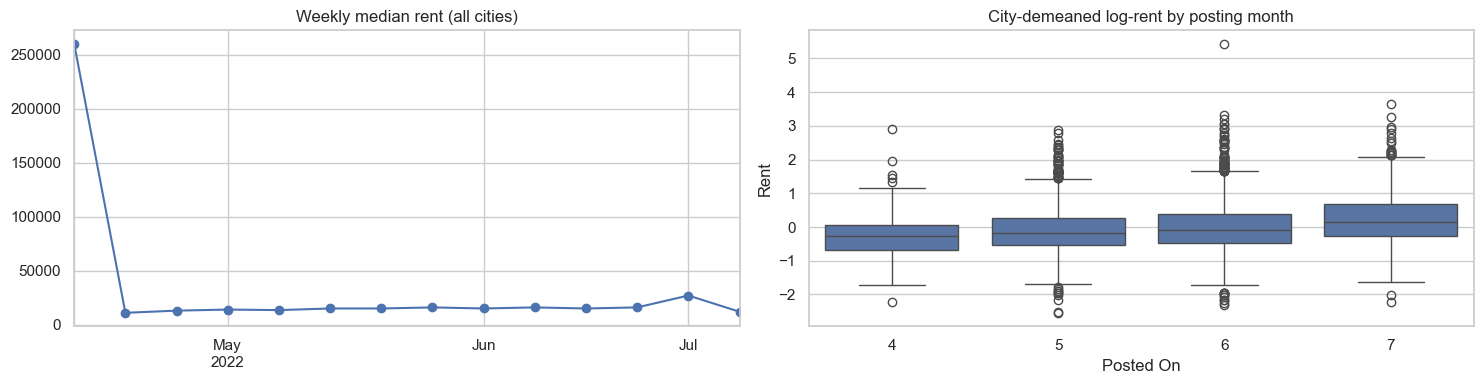

In [16]:
_d = pd.to_datetime(df["Posted On"], errors="coerce")
print("Unparseable dates:", int(_d.isna().sum()))
print("Date range:", _d.min().date(), "→", _d.max().date(), f"({(_d.max() - _d.min()).days} days)")
_month = _d.dt.month
_days = (_d - _d.min()).dt.days
print("Rows per month:", _month.value_counts().sort_index().to_dict())
print("Median rent per month (all cities):", df.groupby(_month)["Rent"].median().to_dict())

# Is any month effect just a city-mix effect? Compare within city.
print("\nMedian rent by month WITHIN city:")
display(df.pivot_table(index="City", columns=_month, values="Rent", aggfunc="median"))
print("City share by month (row %):")
display((pd.crosstab(_month, df["City"], normalize="index") * 100).round(1))

# Partial check: correlation of days-since-earliest with log-rent after removing city means
resid = log_rent - log_rent.groupby(df["City"]).transform("mean")
print("Spearman(days_since_earliest, log_rent)                 :", round(stats.spearmanr(_days, log_rent)[0], 3))
print("Spearman(days_since_earliest, log_rent | city-demeaned) :", round(stats.spearmanr(_days, resid)[0], 3))
print("Day-of-week counts:", _d.dt.dayofweek.value_counts().sort_index().to_dict())
print("eta^2(day-of-week, city-demeaned log_rent):", round(eta_sq(_d.dt.dayofweek, resid), 4))
print("eta^2(month,       city-demeaned log_rent):", round(eta_sq(_month, resid), 4))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
df.assign(_m=_d.dt.to_period("W").dt.start_time).groupby("_m")["Rent"].median().plot(ax=ax[0], marker="o")
ax[0].set_title("Weekly median rent (all cities)"); ax[0].set_xlabel("")
sns.boxplot(x=_month, y=resid, ax=ax[1]); ax[1].set_title("City-demeaned log-rent by posting month")
plt.tight_layout(); plt.show()

## 10. Leakage screen

In [17]:
# Any column that is a near-deterministic function of Rent would be leakage.
for c in df.columns.drop(TARGET):
    if c in num_cols:
        r = stats.spearmanr(df[c], df[TARGET])[0]
        print(f"{c:18s} Spearman with Rent = {r:+.3f}")
print("\nNo column is derived from Rent; none has |rho| close to 1.")
print("All columns are listing attributes available at posting time (incl. Point of Contact, Posted On).")
print("Integrity: df shape still", df.shape, "— nothing modified in this notebook.")

BHK                Spearman with Rent = +0.568


Size               Spearman with Rent = +0.521
Bathroom           Spearman with Rent = +0.663

No column is derived from Rent; none has |rho| close to 1.
All columns are listing attributes available at posting time (incl. Point of Contact, Posted On).
Integrity: df shape still (4746, 12) — nothing modified in this notebook.



## 11. Decisions (output of Phase 1)

Nothing was modified, saved or dropped. Each item is a **decision to carry forward**, tagged with the phase that implements it.
**Rule** means a stateless condition that may run before the split. **Fitted** means a step inside the train-only `Pipeline`/`ColumnTransformer`.

| # | Finding | Decision |
|---|---|---|
| D1 | 4,746 × 12. No ID-like, constant or near-constant columns. `Posted On` is not in the glossary; every other column matches it. The glossary's "Build Area" appears in the data as "Built Area". | Keep all 11 non-target columns as candidates. |
| D2 | **0 missing values**, and no disguised blanks such as "NA" or "-". | No imputation is needed for the raw columns. Parsing `Floor` creates NaNs in 4 rows, so add a **fitted** `SimpleImputer` (strategy set in P2). |
| D3 | 0 exact duplicates. **8 rows are identical except `Posted On`**, i.e. re-posted listings. | P2 **rule**: `drop_duplicates(subset=all cols except "Posted On")` before the split, so one listing can't land in both train and test. |
| D4 | `Floor` has 480 text levels. Current-floor values include "Ground" (927 rows) and "Upper/Lower Basement" (34). 4 rows have no "out of N", and 2 rows have current > total. Spearman ρ with Rent: current floor 0.48, total floors 0.58. | P2/P4 **rule**: parse into `current_floor` (Ground=0, Upper Basement=−1, Lower Basement=−2) and `total_floors`, plus a ratio. Missing totals go to the **fitted** imputer. Drop the raw `Floor` string. |
| D5 | `Posted On` covers only 89 days (13 Apr–11 Jul 2022). A weak upward trend remains after removing city effects (ρ=0.175; month η²=0.03; day-of-week η²=0.01). | P4: test `days_since_earliest` and/or `month` as candidate features. Day-of-week is likely dropped. **No property age.** Drop the raw date string. |
| D6 | Rent is extremely skewed: **skew 21.4**, kurtosis 841, median ₹16k, max ₹35L. **log1p brings skew down to 0.91.** | P3: strong evidence for training on `log1p(Rent)` and reporting in rupees via `expm1`. Also assess `qcut(q=5)` stratified splitting. |
| D7 | Raw-IQR flags 520 rents, mostly genuine Mumbai high-end listings. On the log scale only 116 are flagged (37 with \|z\|>3). One listing is clearly implausible: **₹35,00,000 for 2,500 sqft in Marathahalli, Bangalore** (about ₹1,400/sqft; the 99.9th percentile is about ₹705). | **No hand-deletion.** P2 chooses between (a) keeping all rows with log1p plus robust models, or (b) a rent-per-sqft or log-rent IQR cutoff **computed on train and applied to train only**. Val/test stay intact. |
| D8 | Implausible sizes: **91 rows < 100 sqft** (e.g. a 3 BHK at 10 sqft), and 172 rows with Size/BHK < 100 sqft. These look like unit or entry errors. | P2: handle with a code-derived rule, same policy as D7: a train-derived cutoff applied to train only, or keep and let robust models cope. Keep `Area Type`, because carpet and super area measure size differently (median rent ₹25k vs ₹13k). |
| D9 | Rare levels: `Area Type`="Built Area" (2 rows), `Point of Contact`="Contact Builder" (1), BHK=6 (8), Bathroom 7/10 (4). | P5 **fitted**: `OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=…)` fit on train, so rare levels merge into an "infrequent" bucket. No hand merging. |
| D10 | **`Area Locality` has very high cardinality:** 2,235 levels (47% of rows). 65% of localities appear only once, and 60% of rows sit in localities with fewer than 5 rows. Text normalisation barely helps (2,235 → 2,228). η²=0.84 is inflated by the singletons. | **Never one-hot.** P4 decides between dropping it and a smoothed `TargetEncoder` (cross-fitted) **inside the train-fitted ColumnTransformer**, re-fit per CV fold. |
| D11 | Strongest raw drivers are **City** (Mumbai median ₹52k vs Kolkata ₹8.5k), Bathroom (ρ 0.66), BHK (0.57) and Size (0.52). BHK, Bathroom and Size are inter-correlated at 0.72–0.79. | One-hot `City`. The collinearity matters for linear models (watched in P6/P7). P4 adds `size_per_bhk` and `bath_per_bhk`; consider `log1p(Size)`, since Size skew is 2.3. |
| D12 | **Leakage screen is clean.** No column is derived from Rent, and nothing has \|ρ\| near 1. `Point of Contact` is strongly linked to rent (Agent median ₹45k vs Owner ₹12.5k) and to city (80% of Mumbai listings are via agents), but it is known when the listing is posted. | Keep `Point of Contact` as a legitimate feature. |
